## Lab - EDA Univariate Analysis: Diving into Amazon UK Product Insights

**Objective**: Explore the product listing dynamics on Amazon UK to extract actionable business insights. By understanding the distribution, central tendencies, and relationships of various product attributes, businesses can make more informed decisions on product positioning, pricing strategies, and inventory management.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

In [4]:
# download dataset

import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")

print("Path to dataset files:", path)

100%|██████████| 117M/117M [00:04<00:00, 25.4MB/s] 

Extracting files...


Path to dataset files: C:\Users\anmnu\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("C:/Users/anmnu/.cache/kagglehub/datasets/asaniczka/uk-optimal-product-price-prediction/versions/3/amz_uk_price_prediction_dataset.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


### Part 1: Understanding Product Categories

**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

In [5]:
cat = df.select_dtypes(exclude = "number")
num = df.select_dtypes(include = "number")

In [6]:
cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 4 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   asin          object
 1   title         object
 2   isBestSeller  bool  
 3   category      object
dtypes: bool(1), object(3)
memory usage: 58.3+ MB


1. **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?

In [7]:
# Frequency Tables - Generate a frequency table for the producyt category 

frequency_table = cat.category.value_counts()
frequency_table

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [ ]:
frequency_table.sort_values(ascending = False)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

The top 5 are Sports & Outdoors, Beauty, Handmade Clothing, Shoes & Accessories, Bath & Body, and Birthday Gifts 

2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

In [8]:
import matplotlib.pyplot as plt 
import seaborn as sns 

C:\Users\anmnu\AppData\Local\Temp\ipykernel_18548\3001098092.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


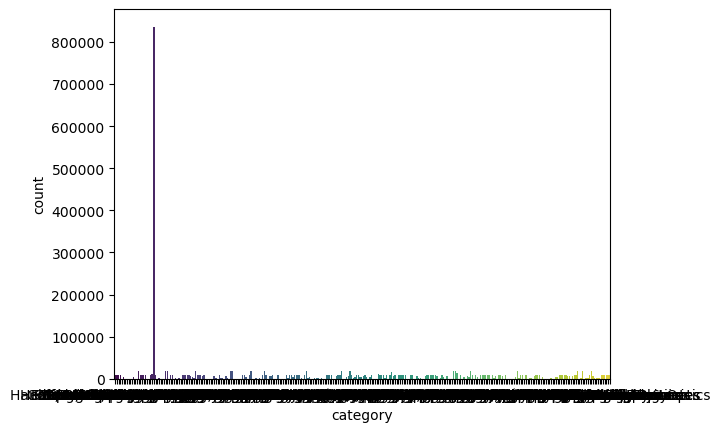

In [ ]:
sns.countplot(
    x="category",
    data=cat,

    palette='viridis',
    legend=False,
)
plt.show()

# Too many, a little messy and not informative 

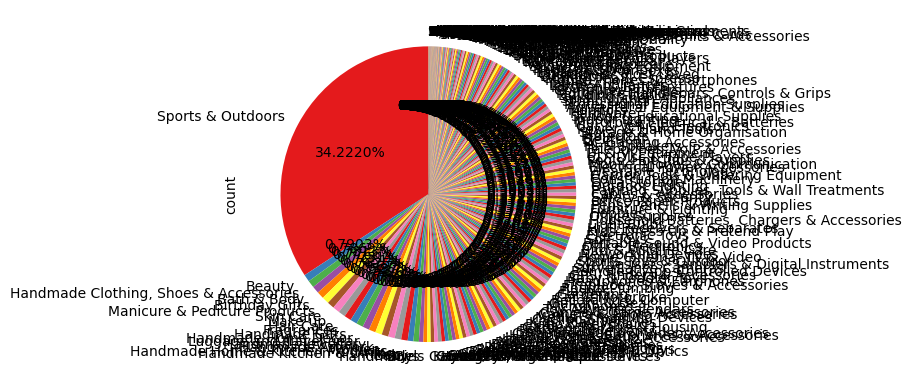

In [9]:
frequency_table.plot.pie(autopct='%1.4f%%' ,startangle=90, colors=sns.color_palette('Set1'))
plt.show()

So here we can see that Sports & Outdoors clearly dominated the category 

### Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?

In [ ]:
num

,uid,stars,reviews,price,boughtInLastMonth
0,1,4.7,15308,21.99,0
1,2,4.7,98099,23.99,0
2,3,4.7,15308,21.99,0
3,4,4.7,7205,31.99,0
4,5,4.6,1881,17.99,0
...,...,...,...,...,...
2443646,2828589,0.0,0,22.34,0
2443647,2828590,0.0,0,97.99,0
2443648,2828591,0.0,0,52.99,0
2443649,2828592,4.3,404,79.99,0


In [14]:
display(num["price"].describe())

count    2.443651e+06
mean     8.924381e+01
std      3.456089e+02
min      0.000000e+00
25%      9.990000e+00
50%      1.909000e+01
75%      4.599000e+01
max      1.000000e+05
Name: price, dtype: float64

In [19]:
print("\nThe mean of the price is", num["price"].mean())
print("\nThe median of the price is", num["price"].median())
print("\nThe mode of the price is", num["price"].mode()[0])



The mean of the price is 89.24380943923661

The median of the price is 19.09

The mode of the price is 9.99


2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?

In [20]:
num["price"].describe()

count    2.443651e+06
mean     8.924381e+01
std      3.456089e+02
min      0.000000e+00
25%      9.990000e+00
50%      1.909000e+01
75%      4.599000e+01
max      1.000000e+05
Name: price, dtype: float64

In [23]:
# IQR range is bascially 75% - 25%
stats = num["price"].describe()
iqr = stats["75%"] - stats["25%"]

print("\nThe standard deviation of the price is", num["price"].std())
print("\nThe variance of the price is", num["price"].var())
print(f"The interquartile range of the price is {iqr:2f}")


The standard deviation of the price is 345.60886175352226

The variance of the price is 119445.48532256528
The interquartile range of the price is 36.000000


From the first glance, the product prices are maybe normally distributed, but a visualization would help us understand it better 

3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 

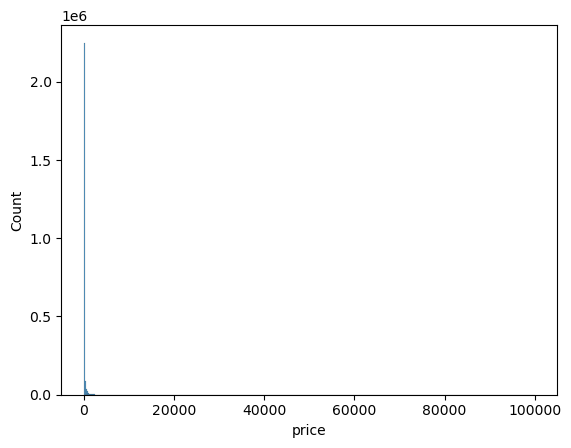

In [27]:
sns.histplot(num.price, bins=500)
plt.show()

So at first glance it was really hard to read the histogram, I think the reason why is because there is some/there are some significant outliers... therefore strechting the histogram very wide

In [33]:
sorting = num["price"].sort_values(ascending = False)
sorting.head(30)

2008013    100000.00
1987238     77752.00
1905315     24674.59
1408966     23482.73
319555      22933.42
1490285     21999.00
1490286     21999.00
1907272     21464.82
1907271     21464.82
1907273     21464.82
1430208     20489.75
1758235     20216.00
1430241     20015.45
1490280     19999.00
1490269     19999.00
1490231     19999.00
1490272     19999.00
367848      19990.00
589336      19290.93
1408974     19211.51
322759      18244.80
2392759     18169.83
2393389     18144.00
2392228     17837.54
2393205     17611.51
1416210     17139.30
1490252     16999.00
1757094     16367.43
2393494     16113.99
864567      16000.00
Name: price, dtype: float64

Or we can do it in a more statistical approach, checking how many values lie outside the Q3 and Q1.. 

In [ ]:
q1 = num["price"].quantile(0.25)
q3 = num["price"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = num[(num["price"] < lower_bound) | (num["price"] > upper_bound)]
outliers.sort_values(by = "price", ascending = False)
print(f"Number of outliers: {len(outliers)}")


Number of outliers: 327688


total number 2443651, here we are 327688 values that are considered outliers. To have a more readable histogram, because we know our data for price is heavily right-skewed, let us plot a histogram without the outliers just to see

In [45]:
df_no_outliers = num[(num["price"] >= lower_bound) & (num["price"] <= upper_bound)]

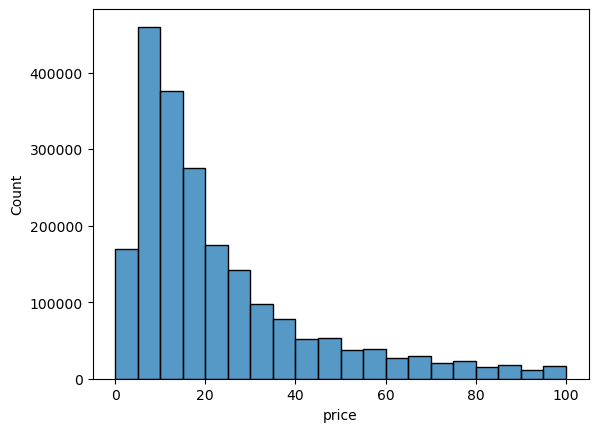

In [48]:
sns.histplot(df_no_outliers.price, bins=20)
plt.show()

### Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?


In [50]:
num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 5 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   stars              float64
 2   reviews            int64  
 3   price              float64
 4   boughtInLastMonth  int64  
dtypes: float64(2), int64(3)
memory usage: 93.2 MB


In [51]:
num.head(10)

,uid,stars,reviews,price,boughtInLastMonth
0,1,4.7,15308,21.99,0
1,2,4.7,98099,23.99,0
2,3,4.7,15308,21.99,0
3,4,4.7,7205,31.99,0
4,5,4.6,1881,17.99,0
5,6,4.7,7205,31.99,0
6,7,4.7,15308,21.99,0
7,8,4.7,103673,39.99,0
8,9,4.7,29909,29.99,0
9,10,4.5,16014,29.99,0


In [53]:
num.describe().round(2)

,uid,stars,reviews,price,boughtInLastMonth
count,2443651.00,2443651.00,2443651.00,2443651.00,2443651.00
mean,1370545.35,2.15,480.63,89.24,25.90
std,816056.17,2.19,5944.12,345.61,240.48
min,1.00,0.00,0.00,0.00,0.00
25%,658921.50,0.00,0.00,9.99,0.00
50%,1349029.00,0.00,0.00,19.09,0.00
75%,2060685.50,4.40,59.00,45.99,0.00
max,2828593.00,5.00,1356658.00,100000.00,50000.00


1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?

In [55]:
print("\nThe mean of the rating (stars) is", num["stars"].mean())
print("\nThe median of the rating (stars) is", num["stars"].median())
print("\nThe mode of the rating (stars) is", num["stars"].mode()[0])


The mean of the rating (stars) is 2.152836472966066

The median of the rating (stars) is 0.0

The mode of the rating (stars) is 0.0


In [59]:
num["stars"].unique()
num["stars"].nunique()
num["stars"].value_counts()

stars
0.0    1225641
4.5     151577
4.6     136995
4.4     136165
5.0     128492
4.3     112564
4.7      94566
4.2      86871
4.0      66089
4.1      65115
4.8      41858
3.9      36555
3.8      27876
3.7      21137
3.6      16219
3.5      14673
3.0      12819
4.9      11081
3.4      10355
1.0       8484
3.3       8269
3.2       5771
3.1       4679
2.0       3901
2.9       3341
2.8       2306
2.7       2104
2.5       2103
2.6       1579
2.4       1060
2.3        734
2.2        602
2.1        540
1.5        404
1.9        300
1.8        249
1.7        177
1.4        149
1.6        147
1.3         78
1.2         23
1.1          3
Name: count, dtype: int64

From median and mode, also from the unique value counts, we can see that a clear majority of customers chose not to leave a reivew

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

In [63]:
stars_stats = num["stars"].describe()
stars_iqr = stars_stats["75%"] - stars_stats["25%"]

print("\nThe standard deviation of the stars/rating is", round(num["stars"].std(), 2))
print("\nThe variance of the stars/rating is", round(num["stars"].var(), 2))
print(f"The interquartile range of the stars/rating is {stars_iqr:2f}")


The standard deviation of the stars/rating is 2.19

The variance of the stars/rating is 4.82
The interquartile range of the stars/rating is 4.400000


Rating/Stars has a scale from 1 to 5, so to see 2.19 as a std is very large. IQR range is 4.4, that is also super huge. In business words, no strong consensus in product rating. 

3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

In [64]:
num["stars"].skew()

np.float64(0.08120735761080881)

In [65]:
num["stars"].kurt()

np.float64(-1.9260061280432994)

The skewness is very close to zero, this is telling us that the distritution is close to normal, so skewness. Negative kurtosis represents very few extreme values or outliers.

4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

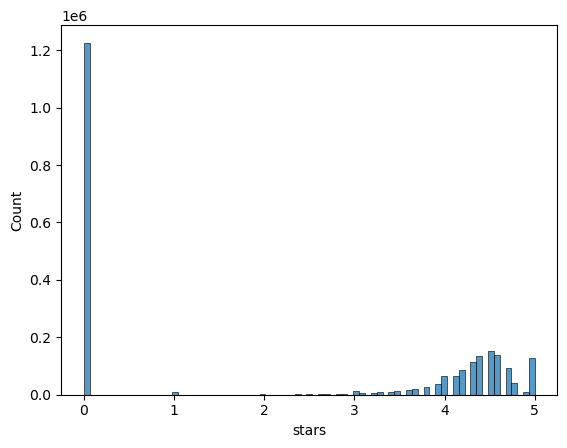

In [66]:
sns.histplot(num.stars, bins="auto")
plt.show()

To draw a conclusion. It is very interesting. From the histogram we see that our histogram and our rating/reviews are zero-inflated. This we can see from getting the median and the mode. The IQR also told us that the distribution of the data is not consistent at all. However, from the skew and the kurtosis we can see that the distribution is very symmetrical. Only that the ratings are dominatead by a lot of zeros. 